# Джем MyIndie LVL 10

# 0. Подготовка

In [21]:
import os
from datetime import datetime
# from pathlib import Path
# import shutil
import json
import requests
import re
import pandas as pd
import numpy as np


# Константы
MYINDIE_JAM_URL = "https://myindie.ru/jams/jam/myindie-level-10"
MYINDIE_JAM_URL_PAGES = 5  # Количество страниц с играми на геймджеме
MYINDIE_JAM_SKIP_DOWNLOAD = True
OUTPUT_DIR = "output/"
CRITERIAS = ["art", "sound", "theme", "devblog", "gameplay", "narrative", "decoration", "overall_impression"]  # Список критериев для анализа

# Директория для html-файлов джема
jam_path = MYINDIE_JAM_URL.split('/')[-1]  # получаем имя джема вроде "myindie-game-jam-level-9"
if jam_path is None or jam_path == "":
    raise ValueError("Не удалось извлечь путь джема из URL. Проверьте правильность MYINDIE_JAM_URL.")
os.makedirs(os.path.join(OUTPUT_DIR, jam_path), exist_ok=True)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', None)


def get_jam_games_urls(jam_url):
    """ Скачивает страницу списка игр джема и извлекает URL игр. """

    response = requests.get(jam_url)

    if response.status_code != 200:
        print(f"Ошибка при получении страницы джема: `{response.status_code}`")
        return []

    games_urls = re.findall(r'/games/game/[\w-]+', response.text)
    games_urls = [f"https://myindie.ru{url}" for url in games_urls]
    print(f"Найдено {len(games_urls)} URL игр в: {jam_url}")

    return games_urls


def unflatten_nuxt_data(data):
    """ Разворачивает плоскую структуру данных Nuxt.js в дерево. """
    if not isinstance(data, list) or not data: return data
    memo = {}
    def resolve(val):
        if isinstance(val, int) and 0 <= val < len(data):
            if val not in memo:
                memo[val] = resolve_item(data[val])
            return memo[val]
        return val
    def resolve_item(item):
        if isinstance(item, dict):
            return {k: resolve(v) for k, v in item.items()}
        if isinstance(item, list):
            return [resolve(v) for v in item]
        return item
    return resolve_item(data[1])

# 1. Скачиваем все страницы игр геймджема

1.1 Ищем все игры джема

In [22]:
if not MYINDIE_JAM_SKIP_DOWNLOAD:
    games_urls = []
    for page in range(1, MYINDIE_JAM_URL_PAGES + 1):
        paged_url = f"{MYINDIE_JAM_URL}/games?page={page}"
        print(f"Обрабатываем страницу: {paged_url}")
        urls = get_jam_games_urls(paged_url)
        games_urls.extend(urls)

    print(f"\nНайдено {len(games_urls)} игр на {MYINDIE_JAM_URL_PAGES} страницах:\n{chr(10).join(games_urls)}")

1.2 Скачать все HTML-страницы игр геймджема

In [23]:
if not MYINDIE_JAM_SKIP_DOWNLOAD:
    jam_games_file_path = os.path.join(OUTPUT_DIR, jam_path, f"jam_games.txt")
    if os.path.exists(jam_games_file_path):
        os.remove(jam_games_file_path)
    jam_games_file = open(jam_games_file_path, 'a', encoding='utf-8')

    # DEBUG_GAMES_MAX = 3  # delete
    for i, game_url in enumerate(games_urls): #[:DEBUG_GAMES_MAX]):
        print(f"Обработка URL игры: {game_url}")
        response = requests.get(game_url)
        if response.status_code != 200:
            print(f"* Ошибка при получении страницы игры: `{response.status_code}`")
            continue

        title_match = re.search(r'<title>([^<]+)</title>', response.text)
        if title_match:
            title = f"{i:03d}_" + re.sub(r'[^\w_]', '-', re.sub(r'\s+', '_', title_match.group(1).strip()))
        else:
            title = f"{i:03d}_" + "Unknown"

        output_file_path = os.path.join(OUTPUT_DIR, jam_path, f"{title}.html")
        with open(output_file_path, 'w', encoding='utf-8') as f:
            f.write(response.text)
            print(f"Сохранено в `{output_file_path}`")
        jam_games_file.write(f"{output_file_path} {game_url}\n")

    jam_games_file.close()

# 2. Извлекаем данные со всех страниц игр
2.1 Используем уже скачанные HTML-страницы игр геймджема, чтобы извлечь данные о каждой игре

In [24]:
jam_games_file_path = os.path.join(OUTPUT_DIR, jam_path, "jam_games.txt")
jam_games_file = open(jam_games_file_path, 'r', encoding='utf-8')
print(f"Всего игр в файле `{jam_games_file_path}`: {len(jam_games_file.readlines())}")

Всего игр в файле `output/myindie-level-10\jam_games.txt`: 144


2.2 Собираем оценки и отзывы для каждой игры из скачанных файлов

In [25]:
all_judges_reviews = []  # без разделения по играм
all_participant_reviews = []  # без разделения по играм
all_users_reviews = []  # без разделения по играм
game_reviews = {}  # отзывы для каждой игры, ключ - alias игры, значение - словарь с отзывами по типам

jam_games_file.seek(0)

for line in jam_games_file:
    output_file_path, game_url = line.strip().split(' ', 1)
    alias = game_url.split('/')[-1]
    print(f"Обработка: {game_url}")
    with open(output_file_path, 'r', encoding='utf-8') as f:
        html_content = f.read()

    match = re.search(r'id=\"__NUXT_DATA__\">([^<]+)</script>', html_content)
    if not match:
        print(f"* Не найден __NUXT_DATA__ в `{output_file_path}`\n")
        continue

    json_data = json.loads(match.group(1))
    unflattened = unflatten_nuxt_data(json_data)
    if not unflattened:
        print(f"* Не удалось развернуть данные Nuxt.js в `{output_file_path}`\n")
        continue

    data_section = unflattened.get('data', [])
    if not data_section:
        print(f"* Не найден раздел 'data' в развернутых данных Nuxt.js в `{output_file_path}`\n")
        continue

    # Берем второй элемент списка (индекс 1) — там словарь с результатами
    if isinstance(data_section, list) and len(data_section) > 1:
        payload_container = data_section[1]
        if not payload_container:
            print(f"* Пустой контейнер в `{output_file_path}`\n")
            continue

        # В словаре берем первый ключ (game<alias>)
        if isinstance(payload_container, dict) and payload_container:
            second_key = list(payload_container.keys())[0]
            games = payload_container[second_key]
            if not games:
                print(f"* Пустой объект игры в `{output_file_path}`\n")
                continue

            # Извлекаем отзывы из game_payload['data']['reviews']
            if isinstance(games, dict):
                inner_data = games.get('data', {})
                if not inner_data:
                    print(f"* Пустой объект 'data' в `{output_file_path}`\n")
                    continue

                reviews = inner_data.get('reviews', [])
                if not reviews:
                    print(f"* Не найдено отзывов в `{output_file_path}`\n")
                    continue
                # print(json.dumps(reviews, ensure_ascii=False, indent=2))

                judges = [r for r in reviews if isinstance(r, dict) and r.get('reviewerType') == 'judge' and r.get('user') is not None]
                all_judges_reviews.extend(judges)
                participants = [r for r in reviews if isinstance(r, dict) and r.get('reviewerType') == 'jam-participant' and r.get('user') is not None]
                all_participant_reviews.extend(participants)
                users = [r for r in reviews if isinstance(r, dict) and r.get('reviewerType') == 'user' and r.get('user') is not None]
                all_users_reviews.extend(users)

                game_reviews[alias] = {
                    'judges': judges,
                    'participants': participants,
                    'users': users,
                    'official_score': inner_data.get('game', {}).get('score', 0)
                }
                print(f"Судейских отзывов: {len(judges)} - {', '.join([r.get('user', {}).get('username') for r in judges])}")
                print(f"Отзывы участников: {len(participants)} - {', '.join([r.get('user', {}).get('username') for r in participants])}")
                print(f"Отзывы пользователей: {len(users)} - {', '.join([r.get('user', {}).get('username') for r in users])}\n")

print(f"\nВсего судейских отзывов на джеме: {len(all_judges_reviews)}")
print(f"Всего отзывов участников на джеме: {len(all_participant_reviews)}")
print(f"Всего отзывов пользователей на джеме: {len(all_users_reviews)}")

Обработка: https://myindie.ru/games/game/my-tedious-routine
Судейских отзывов: 4 - GlebTheBread, Banzai, Vlad_Borets, StrasZakata
Отзывы участников: 6 - xevin, shishinda, SkreT1kk, SPIRONIS, UnrealQW, Gazolina
Отзывы пользователей: 1 - dis1008

Обработка: https://myindie.ru/games/game/manlygun
Судейских отзывов: 4 - DenisTrak, Alex_app1, Markus_Glevera, scrabyq
Отзывы участников: 3 - Sdt, shishinda, ChiFu
Отзывы пользователей: 1 - dis1008

Обработка: https://myindie.ru/games/game/koronka-zhmyot
Судейских отзывов: 6 - HelenAllienPoe, qwinny, GlebTheBread, DenisTrak, Vlad_Borets, Markus_Glevera
Отзывы участников: 4 - UnrealQW, shishinda, ChiFu, Gremlin
Отзывы пользователей: 2 - dis1008, OverLord

Обработка: https://myindie.ru/games/game/rassudok
Судейских отзывов: 2 - Banzai, Polina_Dadabaeva
Отзывы участников: 5 - Skyline_rozan, shishinda, Damsteel, Andy, solo
Отзывы пользователей: 0 - 

Обработка: https://myindie.ru/games/game/sedmoj
Судейских отзывов: 6 - HelenAllienPoe, enutrov, qwin

In [26]:
# inner_data['game']['score']
# game_reviews

In [27]:
jam_games_file.close()

# 3. Обработка данных и анализ

In [28]:
# print(json.dumps(all_judges_reviews, ensure_ascii=False, indent=2))
# print(json.dumps(all_participant_reviews, ensure_ascii=False, indent=2))
# print(json.dumps(all_users_reviews, ensure_ascii=False, indent=2))

3.1 Обрабатываем все судейские отзывы и оценки для каждой игры

In [29]:
# Словари для хранения данных судей
judges_dict = {} # userId -> {"username": username, "reviews": []}

for review in all_judges_reviews:
    if review.get('reviewerType') == 'judge':
        user_id = review.get('userId')
        username = review.get('user', {}).get('username', 'Unknown')

        if user_id not in judges_dict:
            judges_dict[user_id] = {
                "username": username,
                "reviews": []
            }

        judges_dict[user_id]["reviews"].append(review)

judges_dict = dict(sorted(judges_dict.items(), key=lambda item: len(item[1]['reviews']), reverse=True))

print(f"Количество уникальных судей: {len(judges_dict)}")
for user_id, info in judges_dict.items():
    print(f"Судья: {info['username']} (ID: {user_id}) - Обзоров: {len(info['reviews'])}")

# Финальный словарь с идентификацией по username
judges_reviews_by_username = {info['username']: info['reviews'] for info in judges_dict.values()}

Количество уникальных судей: 17
Судья: Alex_app1 (ID: 91d843a5-c489-4aea-ac13-e26907a673ab) - Обзоров: 73
Судья: Markus_Glevera (ID: 891b5229-ce62-4f23-a950-bd7579ef4731) - Обзоров: 68
Судья: scrabyq (ID: 54c7df1b-c80e-4dc6-a11d-0fd2c328f349) - Обзоров: 65
Судья: Vlad_Borets (ID: 5797a548-ec39-4b96-a34c-684b7b41071d) - Обзоров: 56
Судья: AkaZloy (ID: 7505f85d-fde3-4d22-9d50-b7e142e3a616) - Обзоров: 55
Судья: Banzai (ID: 195c769e-c340-4bd7-bda1-a688e332ec9d) - Обзоров: 54
Судья: YaroslavShalashov (ID: 195283e1-48b6-40da-8256-465b81d71d21) - Обзоров: 52
Судья: StrasZakata (ID: 431cb7d7-9108-468b-890e-6befedb80325) - Обзоров: 51
Судья: HelenAllienPoe (ID: db51c67e-9d3c-4e25-a589-ec045a0cdb62) - Обзоров: 51
Судья: Polina_Dadabaeva (ID: e675a96c-32f4-41b6-8a63-0a17e3252ff4) - Обзоров: 51
Судья: GlebTheBread (ID: 9a6f8541-3c77-470f-ae3f-fead27394e9e) - Обзоров: 50
Судья: DenisTrak (ID: 1b4d8917-8493-4dcd-96c8-1e7748137dab) - Обзоров: 50
Судья: enutrov (ID: f1e979b0-6acb-4558-912a-a24bb6539cd

In [30]:
# print(json.dumps(judges_reviews_by_username, ensure_ascii=False, indent=2))

3.1.1 Обрабатываем все отзывы участников джема и оценки для каждой игры

In [31]:
# Словари для хранения данных участников джема
participants_dict = {} # userId -> {"username": username, "reviews": []}

for review in all_participant_reviews:
    if review.get('reviewerType') == 'jam-participant':
        user_id = review.get('userId')
        username = review.get('user', {}).get('username', 'Unknown')

        if user_id not in participants_dict:
            participants_dict[user_id] = {
                "username": username,
                "reviews": []
            }

        participants_dict[user_id]["reviews"].append(review)

participants_dict = dict(sorted(participants_dict.items(), key=lambda item: len(item[1]['reviews']), reverse=True))

print(f"Количество уникальных участников джема: {len(participants_dict)}")
for user_id, info in participants_dict.items():
    print(f"Участник джема: {info['username']} (ID: {user_id}) - Обзоров: {len(info['reviews'])}")

# Финальный словарь с идентификацией по username
participants_reviews_by_username = {info['username']: info['reviews'] for info in participants_dict.values()}

Количество уникальных участников джема: 110
Участник джема: shishinda (ID: a4e48532-b463-4585-addf-3865767100f0) - Обзоров: 143
Участник джема: IlunaShake (ID: a4bce2a2-565b-42fa-ad45-cb3ddaadc3d1) - Обзоров: 88
Участник джема: BehindThePixels (ID: 29989cdc-61da-4ad1-9711-ae567e82d1be) - Обзоров: 46
Участник джема: xevin (ID: adae8aa7-3523-4d47-afe0-dc6923ee1464) - Обзоров: 37
Участник джема: Andy (ID: 6baba22a-e0e6-46f1-b430-83436ab7f05a) - Обзоров: 36
Участник джема: Slamblin (ID: 9b49b276-8e48-4e10-81d8-4372d7e96a0c) - Обзоров: 33
Участник джема: gogoweru (ID: 8e2144cb-4225-492d-abc5-3652374a39bb) - Обзоров: 33
Участник джема: Kuznechik (ID: bef2aca4-409a-4b60-abb0-da60bcd4b620) - Обзоров: 30
Участник джема: ScoobySnacks (ID: 406c4b6e-331a-4c18-977b-a9dbafccb840) - Обзоров: 26
Участник джема: Beshamon (ID: b4831dca-1304-4a11-a1c3-da305af6a004) - Обзоров: 26
Участник джема: SPIRONIS (ID: 98cf62c2-6635-4ef9-9e5f-d66e3dc91db6) - Обзоров: 25
Участник джема: Dibudai (ID: f3c04997-1aa8-48

In [32]:
# print(json.dumps(participants_reviews_by_username, ensure_ascii=False, indent=2))

3.2 Собираем статистику по каждому судье: средний балл, количество оценок, количество отзывов

In [33]:
judges_stats = []

for username, reviews in judges_reviews_by_username.items():
    if not reviews:
        print(f"* Судья {username} не имеет обзоров, пропускаем.")
        continue

    totals = { 'score': [] }
    for criteria in CRITERIAS:
        totals[criteria] = []

    for r in reviews:
        if 'score' in r:
            totals['score'].append(r['score'])

        c = r.get('criterias', {})
        for criteria in CRITERIAS:
            if criteria in c:
                totals[criteria].append(c[criteria])

    judge_row = {
        'username': username,
        'reviews_count': len(reviews)
    }

    for key, values in totals.items():
        judge_row[f'avg_{key}'] = round(sum(values) / len(values), 3) if values else 0

    judges_stats.append(judge_row)

df_judges_stats = pd.DataFrame(judges_stats)

# Вывод результата, отсортированного по среднему баллу
df_judges_stats.sort_values(by='avg_score', ascending=False)


,username,reviews_count,avg_score,avg_art,avg_sound,avg_theme,avg_devblog,avg_gameplay,avg_narrative,avg_decoration,avg_overall_impression
14,qwinny,45,3.909,4.511,3.989,3.567,3.533,4.056,3.767,3.533,4.222
0,Alex_app1,73,3.747,4.199,3.877,3.658,3.452,3.603,3.404,3.973,3.760
3,Vlad_Borets,56,3.527,3.875,3.634,3.688,3.554,3.250,3.321,3.446,3.375
4,AkaZloy,55,3.447,3.782,3.727,3.091,3.273,3.464,3.145,3.482,3.527
9,Polina_Dadabaeva,51,3.400,3.657,3.422,3.402,3.471,2.980,3.196,3.814,3.176
8,HelenAllienPoe,51,3.382,3.833,3.853,3.176,2.961,3.324,3.108,3.373,3.392
7,StrasZakata,51,3.361,3.480,3.412,3.598,3.255,3.039,3.020,3.520,3.539
11,DenisTrak,50,3.254,3.370,3.360,3.240,3.280,3.050,3.030,3.480,3.200
6,YaroslavShalashov,52,3.221,3.798,3.490,2.663,2.952,3.308,2.865,3.288,3.356
12,enutrov,48,3.171,3.802,3.479,3.146,2.750,2.802,2.625,3.573,3.188


3.2.1 Собираем статистику по каждому участнику джема: средний балл, количество оценок, количество отзывов

In [34]:
participants_stats = []

for username, reviews in participants_reviews_by_username.items():
    if not reviews:
        print(f"* Участник джема {username} не имеет обзоров, пропускаем.")
        continue

    totals = { 'score': [] }
    for criteria in CRITERIAS:
        totals[criteria] = []

    for r in reviews:
        if 'score' in r:
            totals['score'].append(r['score'])

        c = r.get('criterias', {})
        for criteria in CRITERIAS:
            if criteria in c:
                totals[criteria].append(c[criteria])

    participant_row = {
        'username': username,
        'reviews_count': len(reviews)
    }

    for key, values in totals.items():
        participant_row[f'avg_{key}'] = round(sum(values) / len(values), 3) if values else 0

    participants_stats.append(participant_row)

df_participants_stats = pd.DataFrame(participants_stats)

# Вывод результата, отсортированного по среднему баллу
df_participants_stats.sort_values(by='avg_score', ascending=False)

,username,reviews_count,avg_score,avg_art,avg_sound,avg_theme,avg_devblog,avg_gameplay,avg_narrative,avg_decoration,avg_overall_impression
109,kikopie,1,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
107,Biba,1,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
84,Ganwords,3,4.767,5.000,4.667,4.667,4.167,5.000,4.667,5.000,5.000
95,Abashit,2,4.600,4.500,5.000,3.000,4.750,5.000,5.000,5.000,4.500
106,Jil,1,4.500,5.000,5.000,4.000,5.000,3.000,5.000,5.000,4.000
9,Beshamon,26,4.192,4.519,4.442,4.442,3.712,4.115,3.731,4.115,4.404
16,ArcasHH,21,4.190,4.286,4.452,4.238,4.452,3.667,3.952,4.810,3.595
90,Topling,2,4.150,4.750,4.000,5.000,4.000,3.000,4.250,4.500,3.500
61,Gazolina,5,4.140,4.500,4.500,4.500,3.500,3.700,4.200,4.100,4.100
66,Ivancorej,4,4.125,4.375,4.500,3.500,3.500,4.125,4.500,4.125,4.250


3.3 Cтатистический анализ: средние оценки, медианы, стандартные отклонения, распределения оценок и длины отзывов

In [35]:
judge_detailed_stats = []

for username, reviews in judges_reviews_by_username.items():
    judge_precise_scores = []
    judge_review_lengths = []

    for r in reviews:
        c = r.get('criterias', {})
        criterial_values = [c[k] for k in CRITERIAS if k in c]

        if criterial_values:
            game_score = sum(criterial_values) / len(criterial_values)
            judge_precise_scores.append(game_score)

        text = r.get('reviewText', '')
        if text:
            clean_text = re.sub(r'<[^>]+>', '', text)
            judge_review_lengths.append(len(clean_text))

    stats = {
        'username': username,
        'min_score': np.min(judge_precise_scores) if judge_precise_scores else 0.0,
        'max_score': np.max(judge_precise_scores) if judge_precise_scores else 0.0,
        'median_score': np.median(judge_precise_scores) if judge_precise_scores else 0.0,
        'std_score': np.std(judge_precise_scores) if judge_precise_scores else 0.0,
        'avg_review_chars': int(np.mean(judge_review_lengths)) if judge_review_lengths else 0.0,
        'min_review_chars': np.min(judge_review_lengths) if judge_review_lengths else 0,
        'max_review_chars': np.max(judge_review_lengths) if judge_review_lengths else 0
    }
    judge_detailed_stats.append(stats)

df_judge_detailed = pd.DataFrame(judge_detailed_stats)

df_judge_final_stats = pd.merge(df_judges_stats, df_judge_detailed, on='username')

cols = ['username', 'reviews_count', 'avg_score', 'median_score', 'std_score', 'min_score', 'max_score', 'avg_review_chars', 'min_review_chars', 'max_review_chars']
df_judge_final_stats[cols].sort_values(by='avg_score', ascending=False)

,username,reviews_count,avg_score,median_score,std_score,min_score,max_score,avg_review_chars,min_review_chars,max_review_chars
14,qwinny,45,3.909,4.000,0.497,2.375,4.750,1270,0,3117
0,Alex_app1,73,3.747,3.938,0.592,2.062,5.000,230,101,481
3,Vlad_Borets,56,3.527,3.594,0.804,1.875,5.000,987,182,3685
4,AkaZloy,55,3.447,3.625,0.802,1.250,4.750,323,172,579
9,Polina_Dadabaeva,51,3.400,3.500,0.853,1.438,4.812,1675,791,2646
8,HelenAllienPoe,51,3.382,3.500,0.765,1.000,4.500,507,110,1506
7,StrasZakata,51,3.361,3.750,1.035,1.062,4.812,738,43,1660
11,DenisTrak,50,3.254,3.344,0.846,1.125,4.750,388,0,1141
6,YaroslavShalashov,52,3.221,3.344,0.753,1.000,4.438,96,7,458
12,enutrov,48,3.171,3.188,0.744,1.500,4.375,225,0,386


3.3.1 Cтатистический анализ: средние оценки, медианы, стандартные отклонения, распределения оценок и длины отзывов

In [36]:
participants_detailed_stats = []

for username, reviews in participants_reviews_by_username.items():
    participant_precise_scores = []
    participant_review_lengths = []

    for r in reviews:
        c = r.get('criterias', {})
        criterial_values = [c[k] for k in CRITERIAS if k in c]

        if criterial_values:
            game_score = sum(criterial_values) / len(criterial_values)
            participant_precise_scores.append(game_score)

        text = r.get('reviewText', '')
        if text:
            clean_text = re.sub(r'<[^>]+>', '', text)
            participant_review_lengths.append(len(clean_text))

    stats = {
        'username': username,
        'min_score': np.min(participant_precise_scores) if participant_precise_scores else 0.0,
        'max_score': np.max(participant_precise_scores) if participant_precise_scores else 0.0,
        'median_score': np.median(participant_precise_scores) if participant_precise_scores else 0.0,
        'std_score': np.std(participant_precise_scores) if participant_precise_scores else 0.0,
        'avg_review_chars': int(np.mean(participant_review_lengths)) if participant_review_lengths else 0.0,
        'min_review_chars': np.min(participant_review_lengths) if participant_review_lengths else 0,
        'max_review_chars': np.max(participant_review_lengths) if participant_review_lengths else 0
    }
    participants_detailed_stats.append(stats)

df_participants_detailed = pd.DataFrame(participants_detailed_stats)

df_participants_final_stats = pd.merge(df_participants_stats, df_participants_detailed, on='username')

cols = ['username', 'reviews_count', 'avg_score', 'median_score', 'std_score', 'min_score', 'max_score', 'avg_review_chars', 'min_review_chars', 'max_review_chars']
df_participants_final_stats[cols].sort_values(by='avg_score', ascending=False)

,username,reviews_count,avg_score,median_score,std_score,min_score,max_score,avg_review_chars,min_review_chars,max_review_chars
109,kikopie,1,5.000,5.000,0.000,5.000,5.000,0.000,0,0
107,Biba,1,5.000,5.000,0.000,5.000,5.000,49.000,49,49
84,Ganwords,3,4.767,4.875,0.241,4.438,5.000,0.000,0,0
95,Abashit,2,4.600,4.594,0.406,4.188,5.000,35.000,16,55
106,Jil,1,4.500,4.500,0.000,4.500,4.500,249.000,249,249
9,Beshamon,26,4.192,4.219,0.339,3.188,4.750,353.000,158,703
16,ArcasHH,21,4.190,4.250,0.374,3.125,4.812,1233.000,240,2969
90,Topling,2,4.150,4.125,0.625,3.500,4.750,0.000,0,0
61,Gazolina,5,4.140,4.312,0.661,2.875,4.812,206.000,124,303
66,Ivancorej,4,4.125,4.375,0.823,2.750,4.938,456.000,377,624


3.4 Больше статистики судей:
* strictness_index (индекс "строгости"): Отрицательный = строгий, Положительный = добрый

Строгость считается от среднего значения оценок, выставленных судьями. Если судья ставит в среднем низкие оценки, то он считается строгим, если высокие -- добрым. Этот индекс может быть полезен для анализа "везучести" игр.

In [37]:
judges_deep_insights = []

all_judges_precise_scores = []
for reviews in judges_reviews_by_username.values():
    for r in reviews:
        c = r.get('criterias', {})
        criterial_values = [c[k] for k in CRITERIAS if k in c]
        if criterial_values:
            all_judges_precise_scores.append(sum(criterial_values) / len(criterial_values))

judges_global_avg = np.mean(all_judges_precise_scores) if all_judges_precise_scores else 0.0

for username, reviews in judges_reviews_by_username.items():
    if not reviews: continue

    judge_precise_scores = []
    judge_review_dates = []

    # Статистика по критериям для этого судьи
    criteria_totals = {k: [] for k in CRITERIAS}

    for r in reviews:
        c = r.get('criterias', {})
        cv = [c[k] for k in CRITERIAS if k in c]
        if cv:
            judge_precise_scores.append(sum(cv)/len(cv))

        for k in CRITERIAS:
            if k in c: criteria_totals[k].append(c[k])

        # Время
        dt_str = r.get('createdAt')
        if dt_str:
            dt = datetime.strptime(dt_str, "%Y-%m-%dT%H:%M:%S.%fZ")
            judge_review_dates.append(dt.date())

    # любимый и нелюбимый критерий (avg)
    crit_avgs = {k: np.mean(v) if v else 0 for k, v in criteria_totals.items()}
    best_crit = max(crit_avgs, key=crit_avgs.get)
    worst_crit = min(crit_avgs, key=crit_avgs.get)

    judge_avg = np.mean(judge_precise_scores) if judge_precise_scores else 0.0

    insight = {
        'username': username,
        'strictness_index': round(judge_avg - judges_global_avg, 3), # Отрицательный = строгий, Положительный = добрый
        'top_criteria': f"{best_crit} ({round(crit_avgs[best_crit], 2)})",
        'bottom_criteria': f"{worst_crit} ({round(crit_avgs[worst_crit], 2)})",
        'active_days': (max(judge_review_dates) - min(judge_review_dates)).days + 1 if judge_review_dates else 0,
        'reviews_per_day': round(len(reviews) / ((max(judge_review_dates) - min(judge_review_dates)).days + 1), 2) if judge_review_dates else 0
    }
    judges_deep_insights.append(insight)

df_judges_insights = pd.DataFrame(judges_deep_insights)

df_judges_insights.sort_values(by='strictness_index')


,username,strictness_index,top_criteria,bottom_criteria,active_days,reviews_per_day
16,CreativeAnatoli,-0.467,theme (5.0),art (1.75),1,2.000
13,DmitriySklyarov,-0.423,art (3.56),theme (2.24),7,6.860
10,GlebTheBread,-0.349,decoration (3.51),sound (2.33),6,8.330
2,scrabyq,-0.261,art (3.41),gameplay (2.72),11,5.910
15,danielstone,-0.244,art (3.39),narrative (2.5),7,4.710
5,Banzai,-0.244,devblog (3.31),overall_impression (2.81),7,7.710
1,Markus_Glevera,-0.162,decoration (4.01),theme (2.02),4,17.000
12,enutrov,-0.109,art (3.8),narrative (2.62),2,24.000
6,YaroslavShalashov,-0.065,art (3.8),theme (2.66),11,4.730
11,DenisTrak,-0.029,decoration (3.48),narrative (3.03),11,4.550


3.4.1 Больше статистики участников джема:
- strictness_index: Отрицательный = строгий, Положительный = добрый

In [38]:
participants_deep_insights = []

all_participants_precise_scores = []
for reviews in participants_reviews_by_username.values():
    for r in reviews:
        c = r.get('criterias', {})
        criterial_values = [c[k] for k in CRITERIAS if k in c]
        if criterial_values:
            all_participants_precise_scores.append(sum(criterial_values) / len(criterial_values))

participants_global_avg = np.mean(all_participants_precise_scores) if all_participants_precise_scores else 0.0

for username, reviews in participants_reviews_by_username.items():
    if not reviews: continue

    participant_precise_scores = []
    participant_review_dates = []

    # Статистика по критериям для этого участника
    criteria_totals = {k: [] for k in CRITERIAS}

    for r in reviews:
        c = r.get('criterias', {})
        cv = [c[k] for k in CRITERIAS if k in c]
        if cv:
            participant_precise_scores.append(sum(cv)/len(cv))

        for k in CRITERIAS:
            if k in c: criteria_totals[k].append(c[k])

        # Время
        dt_str = r.get('createdAt')
        if dt_str:
            dt = datetime.strptime(dt_str, "%Y-%m-%dT%H:%M:%S.%fZ")
            participant_review_dates.append(dt.date())

    # любимый и нелюбимый критерий (avg)
    crit_avgs = {k: np.mean(v) if v else 0 for k, v in criteria_totals.items()}
    best_crit = max(crit_avgs, key=crit_avgs.get)
    worst_crit = min(crit_avgs, key=crit_avgs.get)

    participant_avg = np.mean(participant_precise_scores) if participant_precise_scores else 0.0

    insight = {
        'username': username,
        'strictness_index': round(participant_avg - participants_global_avg, 3), # Отрицательный = строгий, Положительный = добрый
        'top_criteria': f"{best_crit} ({round(crit_avgs[best_crit], 2)})",
        'bottom_criteria': f"{worst_crit} ({round(crit_avgs[worst_crit], 2)})",
        'active_days': (max(participant_review_dates) - min(participant_review_dates)).days + 1 if participant_review_dates else 0,
        'reviews_per_day': round(len(reviews) / ((max(participant_review_dates) - min(participant_review_dates)).days + 1), 2) if participant_review_dates else 0
    }
    participants_deep_insights.append(insight)

df_participants_insights = pd.DataFrame(participants_deep_insights)

df_participants_insights.sort_values(by='strictness_index')


,username,strictness_index,top_criteria,bottom_criteria,active_days,reviews_per_day
92,Ark,-2.087,overall_impression (1.5),art (1.0),7,0.290
6,gogoweru,-1.317,decoration (2.11),art (1.71),5,6.600
45,Heshi,-1.292,art (2.39),decoration (1.5),1,9.000
103,Avantyur1st,-1.243,theme (4.0),narrative (1.0),1,1.000
62,solo,-1.131,decoration (2.4),devblog (1.4),1,5.000
93,Vasiliy,-0.900,devblog (3.0),theme (1.5),4,0.500
87,mx_ruby,-0.806,theme (5.0),overall_impression (1.25),1,2.000
100,krillbat,-0.743,sound (3.5),devblog (1.0),1,1.000
89,pupsich123,-0.743,sound (4.0),overall_impression (1.0),1,2.000
59,Deleted user cd31b449,-0.733,devblog (3.0),overall_impression (1.83),6,1.000


3.5 Визуализация данных: графики распределения оценок судей, графики зависимости оценок от длины отзывов

C:\temp\ipykernel_21076\2479619376.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


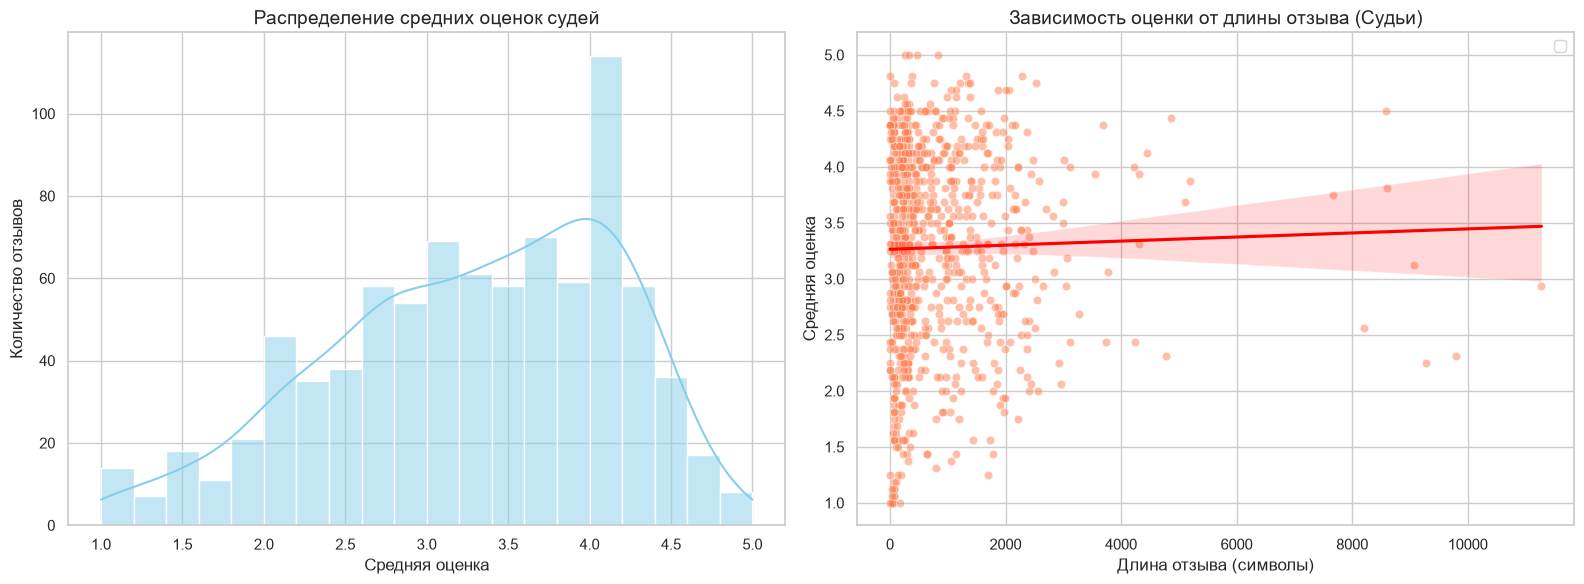

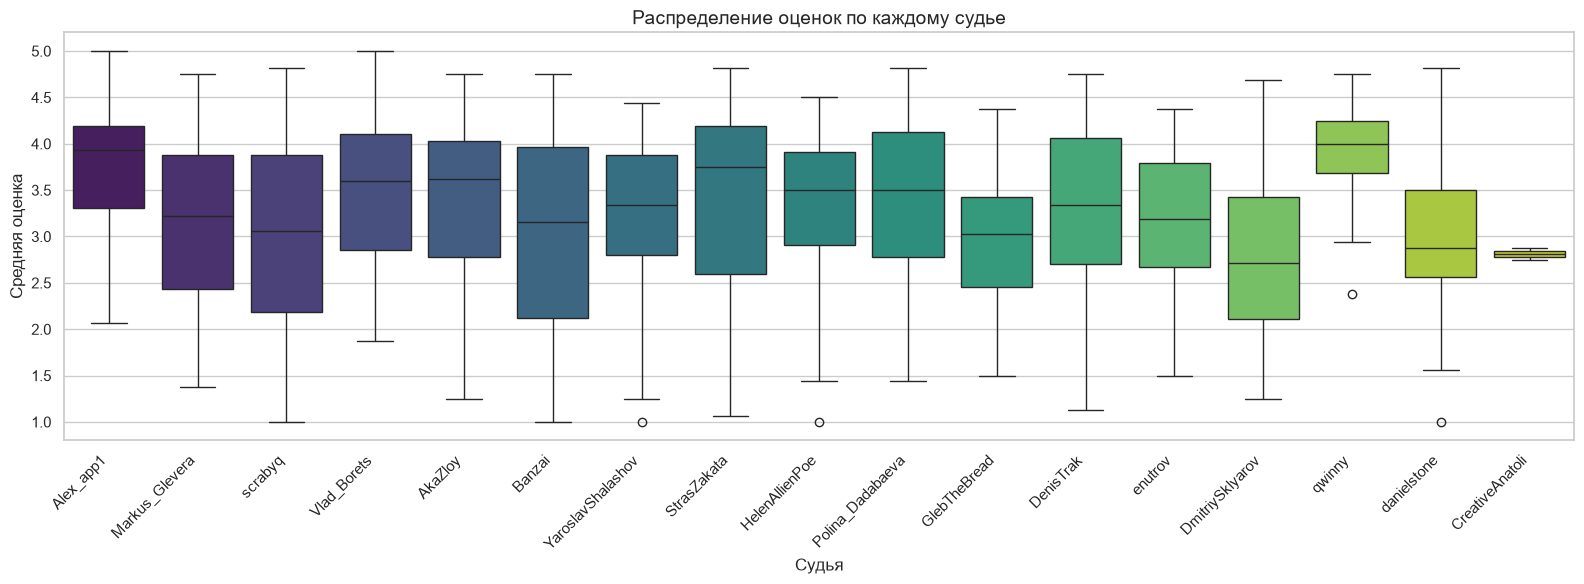

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

judge_plot_data = []
for username, reviews in judges_reviews_by_username.items():
    for r in reviews:
        c = r.get('criterias', {})
        criterial_values = [c[k] for k in CRITERIAS if k in c]
        if criterial_values:
            score = sum(criterial_values) / len(criterial_values)
            text = r.get('reviewText', '')
            clean_text = re.sub(r'<[^>]+>', '', text)
            length = len(clean_text)
            judge_plot_data.append({
                'username': username,
                'score': score,
                'review_length': length
            })

df_judge_plot = pd.DataFrame(judge_plot_data)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_judge_plot['score'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение средних оценок судей', fontsize=14)
axes[0].set_xlabel('Средняя оценка', fontsize=12)
axes[0].set_ylabel('Количество отзывов', fontsize=12)

# Зависимость оценки от длины отзыва
sns.scatterplot(data=df_judge_plot, x='review_length', y='score', alpha=0.5, ax=axes[1], color='coral')
sns.regplot(data=df_judge_plot, x='review_length', y='score', scatter=False, ax=axes[1], color='red', line_kws={"label":"Тренд"})
axes[1].set_title('Зависимость оценки от длины отзыва (Судьи)', fontsize=14)
axes[1].set_xlabel('Длина отзыва (символы)', fontsize=12)
axes[1].set_ylabel('Средняя оценка', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

# Распределение оценок по каждому судье (boxplot)
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_judge_plot, x='username', y='score', hue='username', palette='viridis', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение оценок по каждому судье', fontsize=14)
plt.xlabel('Судья', fontsize=12)
plt.ylabel('Средняя оценка', fontsize=12)
plt.tight_layout()
plt.show()

## 4 "Везучие" и "невезучие" игры

In [40]:
# Словари для быстрого поиска строгости
judge_strictness = df_judges_insights.set_index('username')['strictness_index'].to_dict()
participant_strictness = df_participants_insights.set_index('username')['strictness_index'].to_dict()

# Список для хранения данных об играх
games_data = []

for alias, reviews in game_reviews.items():
    judges = reviews.get('judges', [])
    participants = reviews.get('participants', [])

    # Сбор данных по судьям
    j_info = []
    j_total_strictness = 0
    for r in judges:
        name = r.get('user', {}).get('username')
        strictness = judge_strictness.get(name, 0)
        j_info.append(f" {name} ({strictness})")
        j_total_strictness += strictness

    # Сбор данных по участникам
    p_info = []
    p_total_strictness = 0
    for r in participants:
        name = r.get('user', {}).get('username')
        strictness = participant_strictness.get(name, 0)
        p_info.append(f" {name} ({strictness})")
        p_total_strictness += strictness

    avg_j_strictness = j_total_strictness / len(judges) if judges else 0
    avg_p_strictness = p_total_strictness / len(participants) if participants else 0
    avg_strictness = (avg_j_strictness + avg_p_strictness) / 2

    games_data.append({
        'alias': alias,
        'judges': judges,
        'participants': participants,
        'j_info': j_info,
        'p_info': p_info,
        'avg_j_strictness': avg_j_strictness,
        'avg_p_strictness': avg_p_strictness,
        'avg_strictness': avg_strictness
    })

# Сортировка по сумме строгости (с наименьшей суммой спереди)
games_data.sort(key=lambda x: x['avg_strictness'])

for g in games_data:
    alias = g['alias']
    judges = g['judges']
    participants = g['participants']

    print(f"Игра: {alias}, URL: https://myindie.ru/games/game/{alias}")

    all_scores = [r.get('score', 0) for r in judges + participants]
    avg_score = round(np.mean(all_scores), 3) if all_scores else 0
    official_score = round(game_reviews[alias].get('official_score', 0), 3)

    print(f"Оценка средняя (судьи + участники): {avg_score}. Оценка официальная: {official_score}")
    print(f"Судьи (строгость): {', '.join(g['j_info'])}")
    print(f"Участники (строгость): {', '.join(g['p_info'])}")
    print(f"Строгость (средняя): судей: {round(g['avg_j_strictness'], 3)}, " +
          f"участников: {round(g['avg_p_strictness'], 3)}, " +
          f"общая: {round(g['avg_strictness'], 3)}\n")

Игра: shepot-glubiny, URL: https://myindie.ru/games/game/shepot-glubiny
Оценка средняя (судьи + участники): 2.762. Оценка официальная: 2.75
Судьи (строгость):  Markus_Glevera (-0.162),  GlebTheBread (-0.349),  StrasZakata (0.078),  YaroslavShalashov (-0.065),  scrabyq (-0.261)
Участники (строгость):  shishinda (-0.379),  Slamblin (-0.219),  Dibudai (-0.434),  IcePiecesGames (-0.434),  Kumkvat (-0.437),  gogoweru (-1.317),  Ivancorej (0.928),  ArtemRaz (-0.583),  Andy (-0.254),  AlinkaMalinka (-0.009),  k43nk (-0.702)
Строгость (средняя): судей: -0.152, участников: -0.349, общая: -0.25

Игра: a-special-player, URL: https://myindie.ru/games/game/a-special-player
Оценка средняя (судьи + участники): 2.0. Оценка официальная: 2.15
Судьи (строгость):  GlebTheBread (-0.349),  Polina_Dadabaeva (0.11)
Участники (строгость):  shishinda (-0.379)
Строгость (средняя): судей: -0.119, участников: -0.379, общая: -0.249

Игра: beshenyj-byk_wvp, URL: https://myindie.ru/games/game/beshenyj-byk_wvp
Оценка 

4.1 Корреляции оценок

Коэффициенты корреляции Пирсона:
1. Оценки судей vs Участники: 0.884
2. Кол-во судей vs Средняя оценка: 0.646
3. Везучесть vs Средняя оценка: 0.582
4. Суммарная строгость vs Разница между средней оценкой и официальной: -0.032


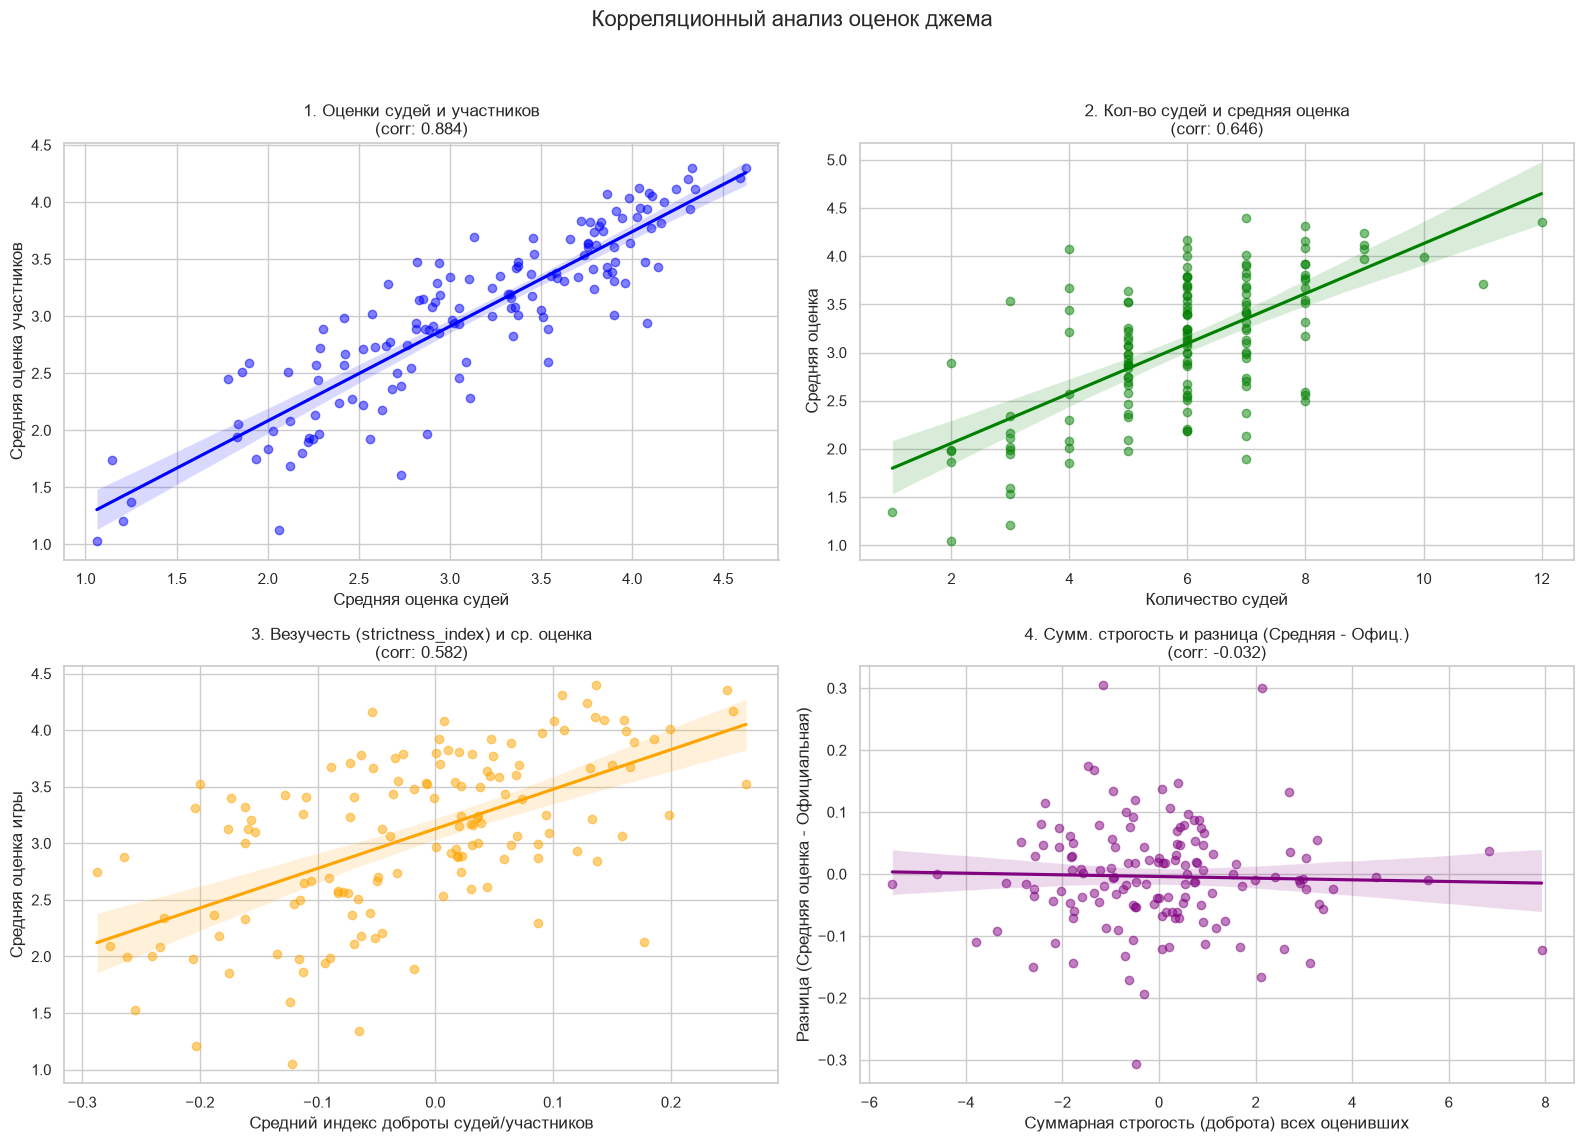

In [ ]:
correlation_data = []

for alias, data in game_reviews.items():
    judges = data.get('judges', [])
    participants = data.get('participants', [])

    if not judges and not participants:
        continue

    # Функция для расчета среднего по критериям (как в 3.5)
    def get_precise_score(r):
        c = r.get('criterias', {})
        cv = [c[k] for k in CRITERIAS if k in c]
        return sum(cv) / len(cv) if cv else r.get('score', 0)

    j_scores = [get_precise_score(r) for r in judges]
    p_scores = [get_precise_score(r) for r in participants]

    avg_j_score = np.mean(j_scores)
    avg_p_score = np.mean(p_scores)

    all_scores = j_scores + p_scores
    avg_score = np.mean(all_scores)
    official_score = data.get('official_score', 0)

    # Расчет "везучести" (средний strictness_index всех оценивших) и "суммарной строгости"
    strictness_indices = []
    for r in judges:
        name = r.get('user', {}).get('username')
        strictness_indices.append(judge_strictness.get(name, 0))
    for r in participants:
        name = r.get('user', {}).get('username')
        strictness_indices.append(participant_strictness.get(name, 0))

    avg_luck = np.mean(strictness_indices)
    total_strictness = sum(strictness_indices)

    correlation_data.append({
        'alias': alias,
        'avg_j_score': avg_j_score,
        'avg_p_score': avg_p_score,
        'avg_score': avg_score,
        'official_score': official_score,
        'n_judges': len(judges),
        'avg_luck': avg_luck,
        'total_strictness': total_strictness,
        'score_diff': avg_score - official_score
    })

df_corr = pd.DataFrame(correlation_data)

# Расчет корреляций
corrs = {
    "1. Оценки судей vs Участники": df_corr[['avg_j_score', 'avg_p_score']].dropna().corr().iloc[0, 1],
    "2. Кол-во судей vs Средняя оценка": df_corr[['n_judges', 'avg_score']].corr().iloc[0, 1],
    "3. Везучесть vs Средняя оценка": df_corr[['avg_luck', 'avg_score']].corr().iloc[0, 1],
    "4. Суммарная строгость vs Разница между средней оценкой и официальной":
        df_corr[['total_strictness', 'score_diff']].corr().iloc[0, 1]
}

print("Коэффициенты корреляции Пирсона:")
for label, val in corrs.items():
    print(f"{label}: {round(val, 3)}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Корреляционный анализ оценок джема', fontsize=16)

# 1. Судьи vs Участники
sns.regplot(data=df_corr, x='avg_j_score', y='avg_p_score', ax=axes[0,0], color='blue', scatter_kws={'alpha':0.5})
axes[0,0].set_title(f"1. Оценки судей и участников\n(corr: {round(corrs['1. Оценки судей vs Участники'], 3)})")
axes[0,0].set_xlabel("Средняя оценка судей")
axes[0,0].set_ylabel("Средняя оценка участников")

# 2. Кол-во судей vs Оценка
sns.regplot(data=df_corr, x='n_judges', y='avg_score', ax=axes[0,1], color='green', scatter_kws={'alpha':0.5})
axes[0,1].set_title(f"2. Кол-во судей и средняя оценка\n(corr: {round(corrs['2. Кол-во судей vs Средняя оценка'], 3)})")
axes[0,1].set_xlabel("Количество судей")
axes[0,1].set_ylabel("Средняя оценка")

# 3. Везучесть vs Оценка
sns.regplot(data=df_corr, x='avg_luck', y='avg_score', ax=axes[1,0], color='orange', scatter_kws={'alpha':0.5})
axes[1,0].set_title(f"3. Везучесть (strictness_index) и ср. оценка\n" +
                    f"(corr: {round(corrs['3. Везучесть vs Средняя оценка'], 3)})")
axes[1,0].set_xlabel("Средний индекс доброты судей и участников")
axes[1,0].set_ylabel("Средняя оценка игры")

# 4. Суммарная строгость vs Разница
sns.regplot(data=df_corr, x='total_strictness', y='score_diff', ax=axes[1,1], color='purple', scatter_kws={'alpha':0.5})
axes[1,1].set_title(f"4. Сумм. строгость и разница (Средняя - Офиц.)\n" +
                    f"(corr: {round(corrs['4. Суммарная строгость vs Разница между средней оценкой и официальной'], 3)})")
axes[1,1].set_xlabel("Суммарная строгость (доброта) всех оценивших")
axes[1,1].set_ylabel("Разница (Средняя оценка - Официальная)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

4.2 Статистические выбросы